In [1]:
## step 1) data cleaning ##

# import necessary tools:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

data = pd.read_csv("/workspaces/DS_project/Cleaned_Data/usa_with_snow.csv")

In [2]:
data["vertical"] = data["Highest point"] - data["Lowest point"]

In [3]:
data.columns

Index(['Resort', 'Country', 'Price', 'Season', 'Highest point', 'Lowest point',
       'Beginner slopes', 'Intermediate slopes', 'Difficult slopes',
       'Total slopes', 'Snow cannons', 'Total lifts', 'Lift capacity',
       'Snowparks', 'Nightskiing', 'latitude', 'longitude', 'Snow',
       'vertical'],
      dtype='object')

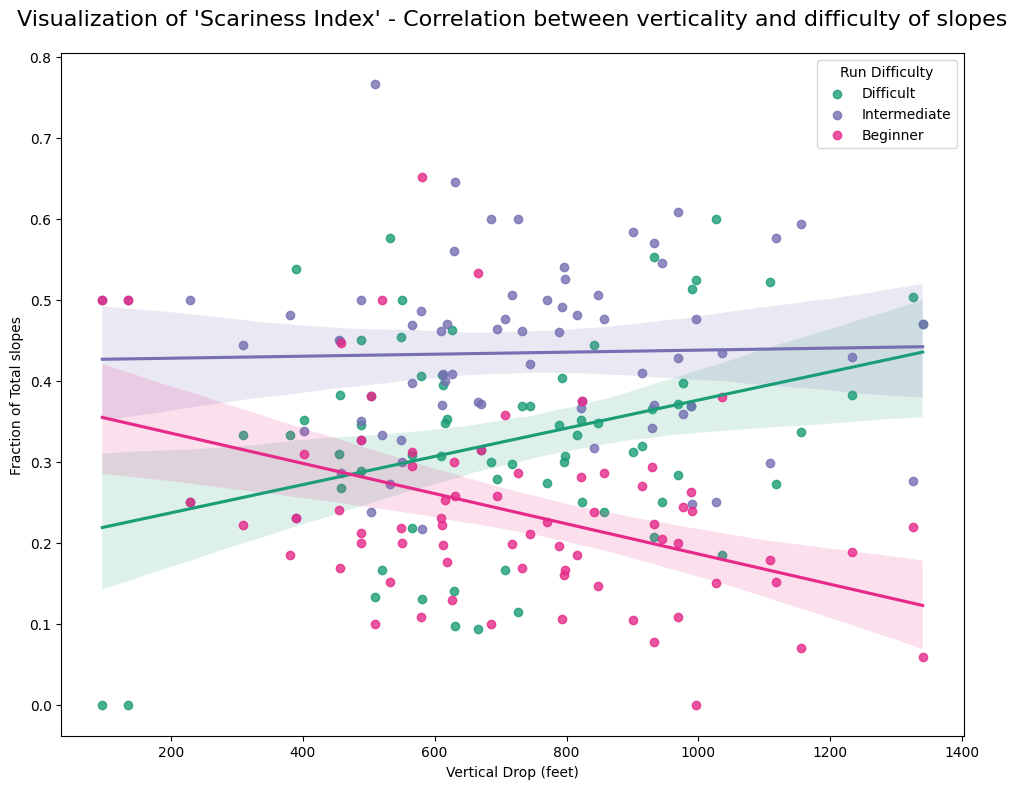

In [4]:
# Hmmm... Based on thata information, you might think, 
#   "That makes sense- of course places like Missouri and Wisconsin wouldn't have many expert slopes
#   while more mountainous places like Wyoming and Montana do."
# Do we see a relationship between how moutnainous a resort is and how difficult the slopes are?

 # dataframe for "difficulty"
diff = pd.DataFrame(index=data.index)
diff["Resort"] = data.get("Resort", data.index)
# add vertical to diff (ensure numeric)



# columns to use:
diff_cols = ["Beginner slopes", "Intermediate slopes", "Difficult slopes"]
total_col = "Total slopes"

# initialize diff with an index and identifier column
diff = pd.DataFrame(index=data.index)
diff["Resort"] = data.get("Resort", data.index)
diff["vertical"] = pd.to_numeric(data.get("vertical", pd.Series(index=data.index)), errors="coerce")
# add resort location/state to diff

for c in diff_cols:
    data[c] = pd.to_numeric(data[c].astype(str).str.replace(",", "", regex=False), errors="coerce")
    base_name = c.lower().replace(" ", "_")      # e.g. "beginner_slopes"
    frac_col = f"{base_name}_frac"               # fraction of total slopes

    diff[frac_col] = data[c] / data[total_col]

# handle infinite results and keep NaNs for missing/zero totals
diff.replace([np.inf, -np.inf], np.nan, inplace=True)


## "diff" is a dataframe containing the decimal fraction of different run difficulties
# verticality vs % difficult slopes (or what I'm calling: scariness index)
import scipy

plt.figure(figsize= (10,8))
col = sns.color_palette("Dark2", 4)
sc_in = sns.regplot(x = data["vertical"], y = diff["difficult_slopes_frac"], color = col[0], label = "Difficult")

sc_in_neg1 = sns.regplot(x = data["vertical"], y = diff["intermediate_slopes_frac"], color = col[2], label = "Intermediate")

sc_in_neg2 = sns.regplot(x = data["vertical"], y = diff["beginner_slopes_frac"], color = col[3], label = "Beginner")


# sc_in_comb = sns.regplot(x = data["vertical"], y = diff["advanced_slopes_frac"] + diff ["expert_slopes_frac"])
    # combined expert and advanceed slopes
plt.legend(title="Run Difficulty", loc='best')
plt.xlabel("Vertical Drop (feet)")
plt.ylabel("Fraction of Total slopes")
plt.title("Visualization of 'Scariness Index' - " \
"Correlation between verticality and difficulty of slopes", 
          fontsize = 16, pad = 20)

plt.tight_layout()
plt.show()
# this plot shows how the % of run difficulty is related to the verticality (slope) of the resort
    # the most positive slope is expert, and the most negative is beginner, which makes sense!

In [5]:
diff.columns

Index(['Resort', 'vertical', 'beginner_slopes_frac',
       'intermediate_slopes_frac', 'difficult_slopes_frac'],
      dtype='object')

In [6]:

# Okay since there's a relationship, I would consider resorts with steep AND difficult slopes "scarier" than those with little verticality and easier slopes.
    # Therefore, let's assign each resort a "Scariness Index" as a function of a "difficulty score" * vertical
    # (difficulty score is a weighted sum of the % of slopes of each difficulty level)
## calculating a "Scariness Index"
Resort_diff_byFrac = diff[["Resort", "vertical", "beginner_slopes_frac", "intermediate_slopes_frac", "difficult_slopes_frac"]]
Resort_diff_byFrac.head()

cols = ["Beginner slopes", "Intermediate slopes", "Difficult slopes"]

# assign weights to difficulties
weights = {"beginner_slopes_frac": 1, "intermediate_slopes_frac": 2, "difficult_slopes_frac": 3}


# loop for calculating a difficulty score (weighted sum of each resort)
for idx, row in Resort_diff_byFrac.iterrows():
    score = 0.0
    for col, w in weights.items():
        v = row.get(col, 0)
        # skip when value is 0 so scores aren't 0 from multiplicaiton
        if pd.isna(v) or v == 0:
            continue
        score += float(v) * w
    Resort_diff_byFrac.at[idx, "difficulty_score_byFrac"] = score

## calculate "scariness index" value ##
    # defined as "difficulty score" * "vertical"
Resort_diff_byFrac["ScarinessIndex"] = Resort_diff_byFrac["vertical"]*Resort_diff_byFrac["difficulty_score_byFrac"]
Resort_diff_byFrac.head()

,Resort,vertical,beginner_slopes_frac,intermediate_slopes_frac,difficult_slopes_frac,difficulty_score_byFrac,ScarinessIndex
0,Steamboat,1118,0.151515,0.575758,0.272727,2.121212,2371.515152
1,Howelsen Hill-Steamboat Springs,135,0.500000,0.500000,0.000000,1.500000,202.500000
2,Crested Butte,933,0.223140,0.570248,0.206612,1.983471,1850.578512
3,Park City,969,0.108000,0.608000,0.284000,2.176000,2108.544000
4,Arapahoe Basin,504,0.380952,0.238095,0.380952,2.000000,1008.000000


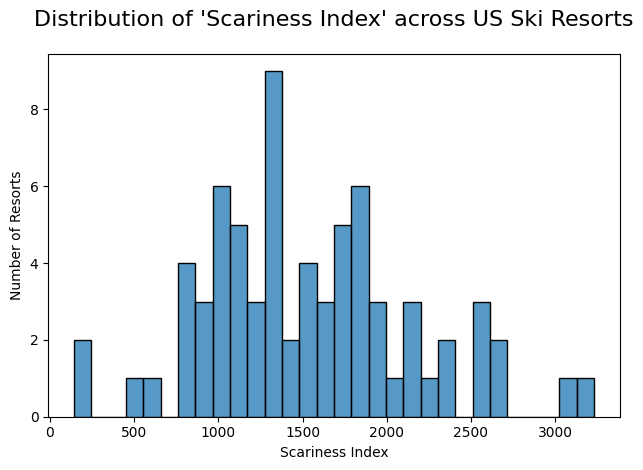

In [7]:
sns.histplot(Resort_diff_byFrac["ScarinessIndex"].dropna(), bins=30)
plt.title("Distribution of 'Scariness Index' across US Ski Resorts", fontsize=16, pad=20)
plt.xlabel("Scariness Index")
plt.ylabel("Number of Resorts")
plt.tight_layout()
plt.show()

Regression stats: slope=498.62640057246347, intercept=-320.0162643222834, rvalue=0.42413775286893446, pvalue=0.00022776494267022675, stderr=128.16784914277946


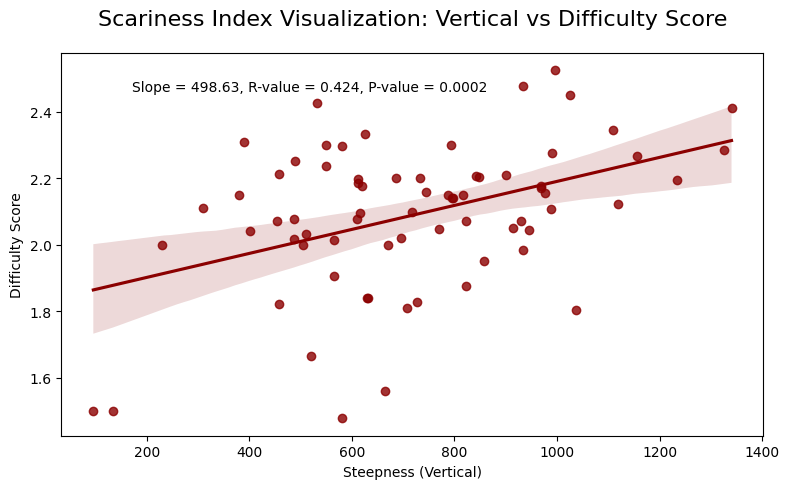

In [8]:
# visualizing scariness via regression plot:
fig2 = plt.figure(figsize= (8, 5))
sns.regplot(data = Resort_diff_byFrac, x = "vertical", y = "difficulty_score_byFrac", color = "DarkRed")
plt.title("Scariness Index Visualization: Vertical vs Difficulty Score", fontsize = 16, pad = 20)
plt.xlabel("Steepness (Vertical)")
plt.ylabel("Difficulty Score")
stats = scipy.stats.linregress(Resort_diff_byFrac["difficulty_score_byFrac"], Resort_diff_byFrac["vertical"])
print(f"Regression stats: slope={stats.slope}, intercept={stats.intercept}, rvalue={stats.rvalue}, pvalue={stats.pvalue}, stderr={stats.stderr}")
plt.annotate("Slope = 498.63, R-value = 0.424, P-value = 0.0002", xy=(0.1, 0.9), xycoords='axes fraction')
plt.tight_layout()
plt.show()

In [9]:
plt.figure(figsize = (10,7))
US_Prices["Season Pass Adult"] = US_Prices["Season Pass Adult"].dropna().astype("float64")
US_Prices["Days Open This Season"] = US_Prices["Days Open This Season"].dropna().astype("Int64")
sns.regplot(data = US_Prices, x = "Season Pass Adult", y = "Days Open This Season", color="DarkRed")
scipy.stats.linregress(US_Prices["Season Pass Adult"], US_Prices["Days Open This Season"])
print(scipy.stats.linregress(US_Prices["Season Pass Adult"], US_Prices["Days Open This Season"]))
plt.title("Season Length vs Adult Season Pass Price", fontsize = 16, pad = 20)
plt.xlabel("Adult Season Pass Price (USD)")
plt.ylabel("Recent Season Length (Days)")
# plt.annotate("Slope = 1635.69, P-value = 0.0006", xy=(0.1, 0.9), xycoords='axes fraction') --> stats aren't working :(
plt.tight_layout()
plt.show()


NameError: name 'US_Prices' is not defined

<Figure size 1000x700 with 0 Axes>

In [92]:
data["beginner_slopes_frac"] = diff["beginner_slopes_frac"]
data["intermediate_slopes_frac"] = diff["intermediate_slopes_frac"]
data["difficult_slopes_frac"] = diff["difficult_slopes_frac"]
data["ScarinessIndex"] = Resort_diff_byFrac["ScarinessIndex"]
data["difficulty_score_byFrac"] = Resort_diff_byFrac["difficulty_score_byFrac"]
data.head()
dataNew = data.copy()

In [87]:
dataNew["Season"].unique()

toreplace = ("November - April", "October - June", "December - April", "November - May", "October - May", 
             "November - June", "October - April", "Unknown", "December - March")
replacewith = ("6", "9", "5", "7", "8", "8", "7", "NaN", "4")
dataNew["Season"] = dataNew["Season"].replace(toreplace, replacewith)
dataNew["Season"] = dataNew["Season"].astype("Int64").dropna()

In [93]:
season_map = {
    "November - April": "6",
    "October - June": "9",
    "December - April": "5",
    "November - May": "7",
    "October - May": "8",
    "November - June": "8",
    "October - April": "7",
    "Unknown": "NaN",
    "December - March": "4"
}
dataNew["Season"] = dataNew["Season"].map(season_map)
dataNew["Season"] = pd.to_numeric(dataNew["Season"], errors="coerce")

In [98]:
print(dataNew["Season"].unique())
print(dataNew["Season"].value_counts())

[ 6.  9.  5.  7.  8. nan  4.]
Season
6.0    45
5.0    11
7.0     6
8.0     2
4.0     2
9.0     1
Name: count, dtype: int64


In [99]:
dataNew.head()

,Resort,Country,Price,Season,Highest point,Lowest point,Beginner slopes,Intermediate slopes,Difficult slopes,Total slopes,...,Nightskiing,latitude,longitude,Snow,vertical,beginner_slopes_frac,intermediate_slopes_frac,difficult_slopes_frac,ScarinessIndex,difficulty_score_byFrac
0,Steamboat,United States,120,6.0,3221,2103,25,95,45,165,...,Yes,35.875,-109.875,13.230000,1118,0.151515,0.575758,0.272727,2371.515152,2.121212
1,Howelsen Hill-Steamboat Springs,United States,21,6.0,2175,2040,1,1,0,2,...,No,40.375,-106.875,79.658333,135,0.500000,0.500000,0.000000,202.500000,1.500000
2,Crested Butte,United States,98,6.0,3707,2774,27,69,25,121,...,No,38.875,-106.875,77.215000,933,0.223140,0.570248,0.206612,1850.578512,1.983471
3,Park City,United States,97,6.0,3049,2080,27,152,71,250,...,Yes,40.625,-111.375,74.184286,969,0.108000,0.608000,0.284000,2108.544000,2.176000
4,Arapahoe Basin,United States,83,9.0,3790,3286,40,25,40,105,...,No,40.125,-80.625,20.866667,504,0.380952,0.238095,0.380952,1008.000000,2.000000


In [100]:
# changing "Yes" and "No" into numeric binary
dataNew["Nightskiing"].replace("Yes", "1", inplace=True)
dataNew["Nightskiing"].replace("No", "0", inplace=True)
dataNew["Nightskiing"] = pd.to_numeric(dataNew["Nightskiing"], errors="coerce", downcast="integer")
dataNew["Nightskiing"].dropna()

dataNew["Snowparks"].replace("Yes", "1", inplace=True)
dataNew["Snowparks"].replace("No", "0", inplace=True)
dataNew["Snowparks"] = pd.to_numeric(dataNew["Snowparks"], errors="coerce", downcast="integer")
dataNew["Snowparks"].dropna()

/tmp/ipykernel_7672/3374138475.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataNew["Nightskiing"].replace("Yes", "1", inplace=True)
/tmp/ipykernel_7672/3374138475.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

0     1
1     0
2     1
3     1
4     1
     ..
66    1
67    0
68    1
69    1
70    1
Name: Snowparks, Length: 71, dtype: int8

In [101]:

# change variables to be used in regression model to numeric types
dataNew["Snow cannons"] = pd.to_numeric(dataNew["Snow cannons"], errors="coerce", downcast="integer")
dataNew.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Resort                    71 non-null     object 
 1   Country                   71 non-null     object 
 2   Price                     71 non-null     int64  
 3   Season                    67 non-null     float64
 4   Highest point             71 non-null     int64  
 5   Lowest point              71 non-null     int64  
 6   Beginner slopes           71 non-null     int64  
 7   Intermediate slopes       71 non-null     int64  
 8   Difficult slopes          71 non-null     int64  
 9   Total slopes              71 non-null     int64  
 10  Snow cannons              71 non-null     int16  
 11  Total lifts               71 non-null     int64  
 12  Lift capacity             71 non-null     int64  
 13  Snowparks                 71 non-null     int8   
 14  Nightskiing 

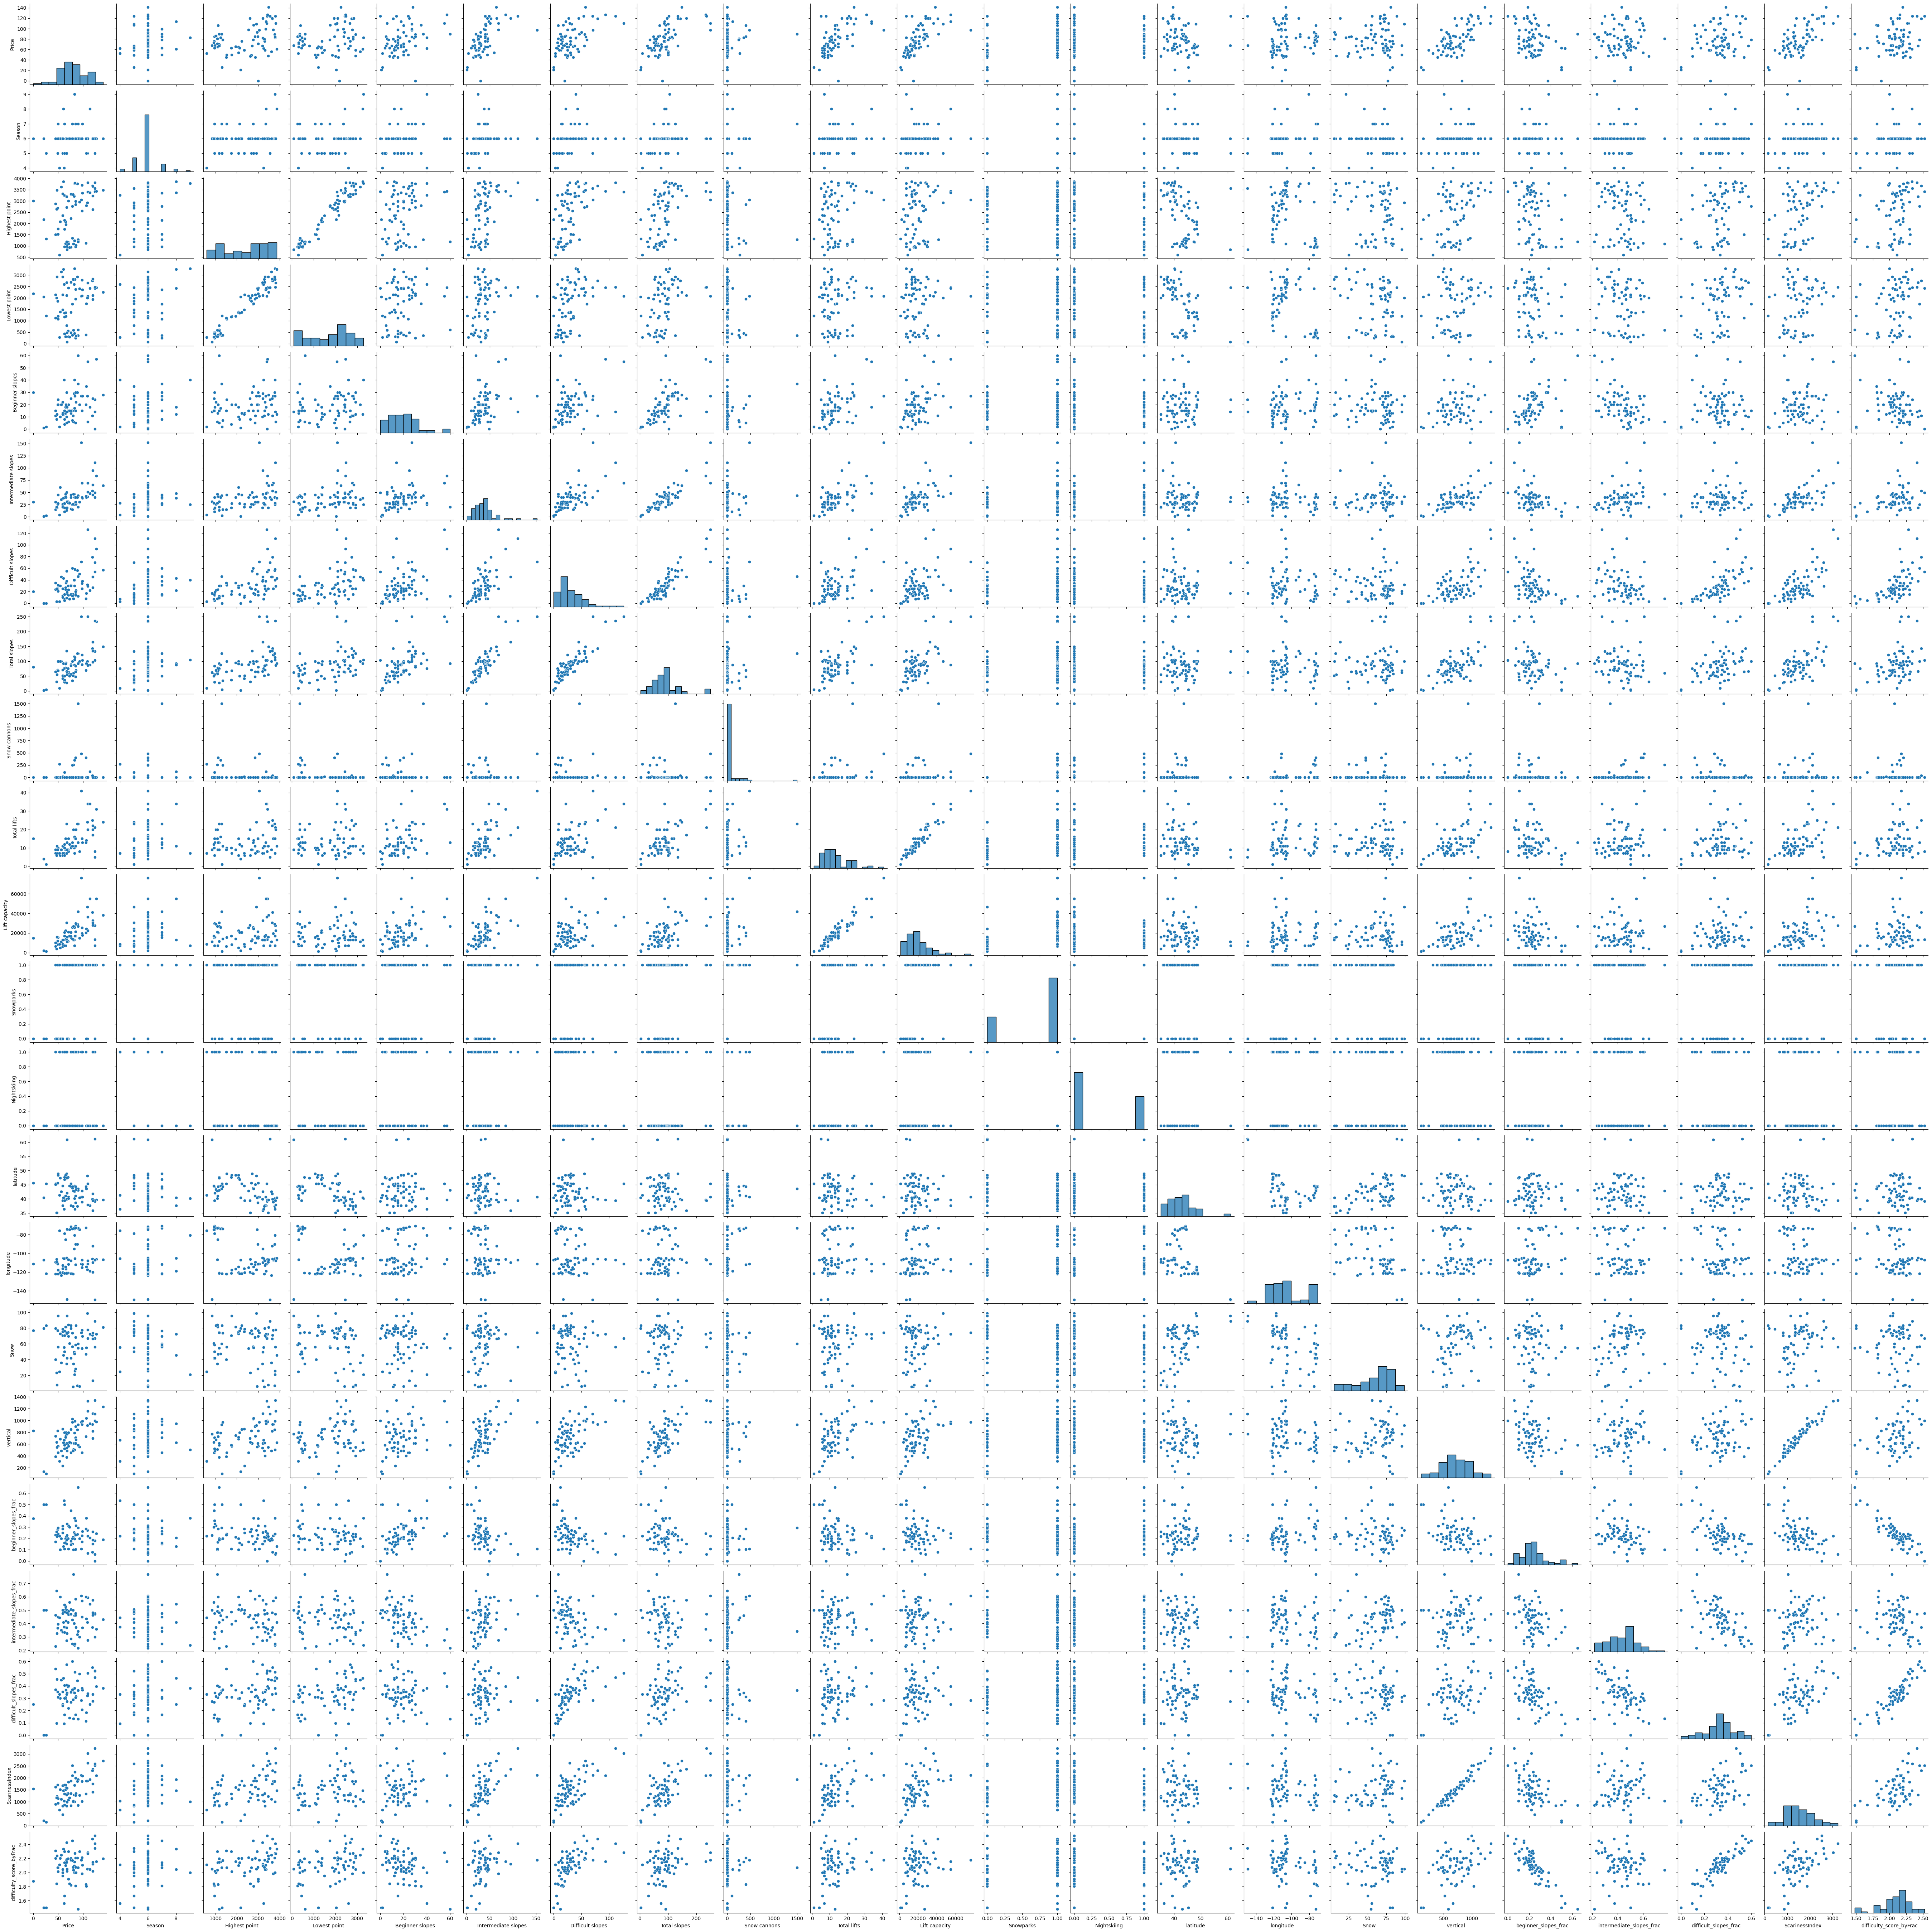

In [109]:
# check for linear relationships between variables
# plot all variables against Price:
sns.pairplot(dataNew)

In [104]:
## running an OLS for price prediction ##
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Define the model formula
feature_cols = ["Season", "Highest point", "Lowest point", "Total slopes", 
         "Snow cannons", "Total lifts", "Lift capacity", "Snowparks", "Nightskiing", "Snow", "vertical", 
         "beginner_slopes_frac","intermediate_slopes_frac", "difficult_slopes_frac", "ScarinessIndex",
         "difficulty_score_byFrac"]

# Create X and Y, then drop rows where either has missing values
X = dataNew[feature_cols].copy()
Y = dataNew["Price"].copy()

# Drop rows with missing values in either X or Y
valid_idx = X.dropna().index.intersection(Y.dropna().index)
X = X.loc[valid_idx]
Y = Y.loc[valid_idx]

X = sm.add_constant(X)

model = sm.OLS(Y, X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.616
Model:                            OLS   Adj. R-squared:                  0.522
Method:                 Least Squares   F-statistic:                     6.545
Date:                Tue, 09 Dec 2025   Prob (F-statistic):           3.32e-07
Time:                        15:07:44   Log-Likelihood:                -284.31
No. Observations:                  67   AIC:                             596.6
Df Residuals:                      53   BIC:                             627.5
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       23.5167     14.604      1.610      0.113      -5.774      52.808
Season                      -1.3668      3.212     -0.426      0.672      -7.810       5.076
Highest point               -0.0027      0.024     -0.110      0.913      -0.052       0.046
Lowest point                 0.0050      0.024      0.206      0.837      -0.044       0.054
Total slopes                 0.0341      0.086      0.396      0.694      -0.138       0.206
Snow cannons                -0.0120      0.013     -0.921      0.361      -0.038       0.014
Total lifts                 -1.3519      0.972     -1.391      0.170      -3.301       0.597
Lift capacity                0.0014      0.001      2.642      0.011       0.000       0.003
Snowparks                    4.6502      6.989      0.665      0.509      -9.369      18.669
Nightskiing                  0.7003      5.482      0.128      0.899     -10.296      11.697
Snow                        -0.2213      0.129     -1.709      0.093      -0.481       0.038
vertical                    -0.0077      0.049     -0.158      0.875      -0.105       0.090
beginner_slopes_frac        22.8917     23.365      0.980      0.332     -23.973      69.757
intermediate_slopes_frac    18.4497     16.056      1.149      0.256     -13.755      50.654
difficult_slopes_frac      -17.8247     14.377     -1.240      0.221     -46.662      11.013
ScarinessIndex               0.0284      0.035      0.818      0.417      -0.041       0.098
difficulty_score_byFrac      6.3170     10.194      0.620      0.538     -14.129      26.763
==============================================================================
Omnibus:                       13.302   Durbin-Watson:                   1.813
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               23.170
Skew:                          -0.647   Prob(JB):                     9.30e-06
Kurtosis:                       5.574   Cond. No.                     5.57e+20
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.33e-31. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

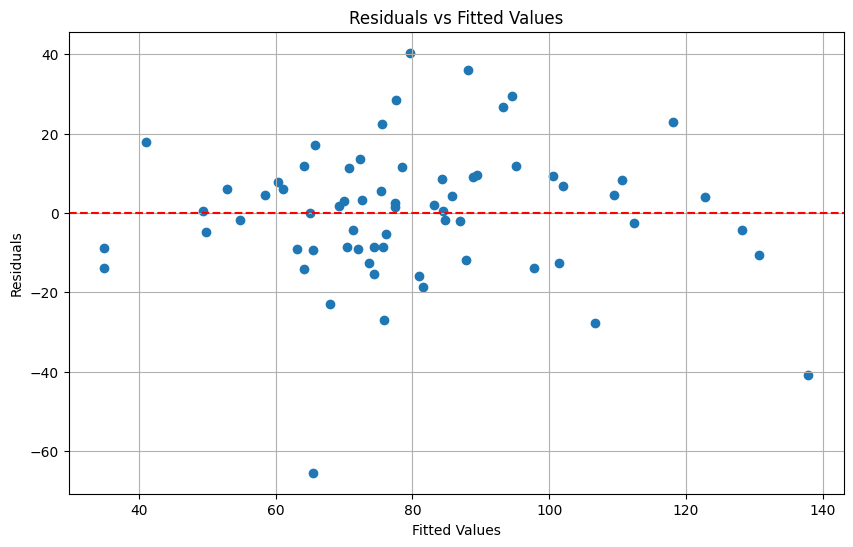

In [105]:
# plot results of OLS
plt.figure(figsize=(10, 6))
plt.scatter(results.fittedvalues, results.resid)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.grid(True)
plt.show()